# Archetype 6 — Base + PV + Heat Pump (HP + Thermal Storage)

## Purpose

Computes the annual TCoE for **Archetype 6: Base + PV (10 kWp) + HP+HS** across 3 strategies x 7 DSOs -> **21 runs**.

PV surplus is allocated to base load first (must-run). Any remaining PV can cover HP electricity, reducing the HP grid import that §14a billing applies to. This creates an interaction between solar self-consumption and heat-pump scheduling that is absent in Archetype 4 (Base + HP).

| Strategy | Flexible resource | Signal |
|---|---|---|
| **no_flex** | None — HP follows HZ2 profile; PV offsets base then HP | none |
| **dt_flex** | LP shifts HP timing | spot (ct/kWh) on net site import |
| **tcoe_flex** | LP per DSO x §14a option | spot + DSO HP-rate + levies on HP grid import |

**§14a applies to HP grid import only** — PV export is always settled at spot (no §14a on feed-in). Base load net of PV and HP grid import are billed separately at the base DSO Arbeitspreis.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 base demand (kWh/slot) |
| `pv_kassel_10kwp_2026_15min.csv` | 10 kWp PV generation Kassel 2026 (kWh/slot) |
| `hp_kassel_hz2_2026_15min.csv` | HP electrical demand profile, Kassel 2026 (kWh/slot) |
| `hp_hz2_parameters_kassel_2026.csv` | COP, HS capacity, q_loss — frozen optimisation parameters |
| `spot_prices_de_lu_2025_15min.csv` | Day-ahead spot price (ct/kWh) |
| `dso_tariffs_residential_2026.csv` | Residential base tariffs + §14a module parameters |
| `dso_mod3_timebands_2026.csv` | §14a Modul 3 HT/NT/ST timeband rules per DSO |
| `residential_taxes_2026.csv` | German levies (ct/kWh, pre-VAT) |

## Output (`outputs/`)

`results_base_pv_hp_2026.csv` — 21 rows x cost-component columns.

## Billing convention

Net spot cost (import * spot - feedin * spot). DSO volumetric split: base import billed at base Arbeitspreis; HP grid import billed under selected §14a option. Single 19% VAT on full net subtotal.

## Solver

Gurobi via PuLP. LP (continuous) at 15-min resolution (T = 35,040). Max 7 x 3 = 21 LP solves for `tcoe_flex`.

## Thesis reference

Chapter 5, Section 5.1 — Results: Archetype 6 (Base + PV + HP)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f'Repo root (containing {marker}) not found.')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')


Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and HP parameters

In [2]:
# Base demand (H25)
base_demand = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv',
                          parse_dates=['timestamp'])

# PV generation (10 kWp, Kassel 2026) — column is 'datetime' (not 'timestamp'); rename on load
pv_df = pd.read_csv(INPUTS / 'pv_kassel_10kwp_2026_15min.csv',
                    parse_dates=['datetime'])
pv_df = pv_df.rename(columns={'datetime': 'timestamp', 'energy_kWh': 'pv_kWh'})

# HP electrical demand profile (HZ2, Kassel 2026) — 'datetime' column, rename for consistency
hp_profile = pd.read_csv(INPUTS / 'hp_kassel_hz2_2026_15min.csv',
                         parse_dates=['datetime'])
hp_profile = hp_profile.rename(columns={'datetime': 'timestamp'})

# Spot prices
spot = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv',
                   parse_dates=['timestamp'])

# Merge all time series onto one aligned index
df = (base_demand
      .merge(pv_df[['timestamp', 'pv_kWh']], on='timestamp')
      .merge(hp_profile[['timestamp', 'energy_kWh']], on='timestamp')
      .merge(spot[['timestamp', 'price_ct_kWh']], on='timestamp'))
df['price_ct_kWh'] = df['price_ct_kWh'].ffill().bfill()
n = len(df)

# ── HP physical parameters (frozen at export time in input notebook 05) ────────
hp_params   = pd.read_csv(INPUTS / 'hp_hz2_parameters_kassel_2026.csv',
                           index_col='parameter')['value']
COP         = float(hp_params['opt_COP_constant'])
q_loss_HS   = float(hp_params['opt_q_losses_HS_per_h'])
P_HP_max_el = float(hp_params['opt_Q_HP_max_el_kW'])   # frozen: 1.2 x peak(HZ2 power_kW)
Q_HP_max_th = P_HP_max_el * COP
E_HS_max    = float(hp_params['opt_HS_capacity_hours']) * Q_HP_max_th  # 2h * Q_HP_max_th (Stute)

hp_p = {'COP': COP, 'q_loss_HS': q_loss_HS, 'Q_HP_max_th': Q_HP_max_th, 'E_HS_max': E_HS_max}

# ── Levies and tariffs ──────────────────────────────────────────────────────────
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region'] == 'DE', 'Total_no_VAT_ct_kWh'].iloc[0])
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
SMART_OP_EUR = 100.0
VAT_RATE     = 0.19

# ── Core arrays ──────────────────────────────────────────────────────────────────
dt_h          = 0.25
q_base        = df['demand_kwh'].values    # [kWh/slot] base electricity demand
pv_arr        = df['pv_kWh'].values        # [kWh/slot] PV generation
E_hp_profile  = df['energy_kWh'].values    # [kWh/slot] HP electrical demand (no-flex profile)
spot_arr      = df['price_ct_kWh'].values  # [ct/kWh]

# Thermal heat demand = E_hp_el * COP (input to the LP heat-balance constraint)
Q_heat_kWh    = E_hp_profile * COP        # [kWh_th/slot]

# ── No-flex PV allocation (base first) ─────────────────────────────────────────
# Convention: PV covers base load first (must-run), surplus goes to HP then feed-in.
# This defines 'base_import' and 'pv_surplus' which are also used in billing.
pv_to_base    = np.minimum(pv_arr, q_base)   # PV energy offsetting base demand
base_import   = q_base - pv_to_base           # base electricity still drawn from grid
pv_surplus    = pv_arr - pv_to_base           # PV remaining after base self-consumption

# HP grid import after PV: max(0, HP site demand - PV surplus available)
E_hp_grid_nf  = np.maximum(0.0, E_hp_profile - pv_surplus)
E_grid_nf     = base_import + E_hp_grid_nf
E_feedin_nf   = np.maximum(0.0, pv_surplus - E_hp_profile)

print(f'T = {n} slots  |  base: {q_base.sum():.1f} kWh  |  PV: {pv_arr.sum():.1f} kWh  |  HP site: {E_hp_profile.sum():.1f} kWh')
print(f'No-flex: grid import {E_grid_nf.sum():.1f} kWh  |  feed-in {E_feedin_nf.sum():.1f} kWh')
print(f'HP params: COP={COP}, Q_HP_max_th={Q_HP_max_th:.1f} kW_th, E_HS_max={E_HS_max:.1f} kWh_th')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh  |  Smart op.: {SMART_OP_EUR} EUR/year')


T = 35040 slots  |  base: 4500.0 kWh  |  PV: 11749.3 kWh  |  HP site: 4500.0 kWh
No-flex: grid import 7138.8 kWh  |  feed-in 9888.0 kWh
HP params: COP=3.2, Q_HP_max_th=20.0 kW_th, E_HS_max=40.0 kWh_th
Levies (pre-VAT): 6.64 ct/kWh  |  Smart op.: 100.0 EUR/year


## Step 2 — §14a Modul 3 schedule

Same §14a structure as Archetype 4, but note the allocation boundary: §14a billing applies only to **HP grid import** (i.e. HP site demand net of PV surplus directed to the HP). PV export earns the spot price and is unaffected by §14a module choice.


In [3]:
MOD3_TIMEBANDS = pd.read_csv(INPUTS / 'dso_mod3_timebands_2026.csv')

def build_hp_dso_rate_mod3(ts_index, dso_name: str, dso_row) -> np.ndarray:
    """Per-slot §14a Modul 3 DSO rate [ct/kWh] for the HP meter. Unassigned slots default to ST."""
    ht = float(dso_row['HT_ct_kWh'])
    nt = float(dso_row['NT_ct_kWh'])
    st = float(dso_row['ST_ct_kWh'])

    T   = len(ts_index)
    idx = pd.to_datetime(ts_index)

    hours  = idx.dt.hour + idx.dt.minute / 60.0
    months = idx.dt.month
    is_q1q4 = (months <= 3) | (months >= 10)
    is_q2q3 = (months >= 4) & (months <= 9)

    rates = np.full(T, st, dtype=float)

    def in_range(h, start, end):
        if start <= end:
            return (h >= start) & (h < end)
        return (h >= start) | (h < end)

    tb = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso_name]
    for band, level in [('NT', nt), ('HT', ht)]:
        for _, r in tb[tb['band'] == band].iterrows():
            qg = str(r['quarter_group'])
            if   qg == 'all':   qmask = np.ones(T, dtype=bool)
            elif qg == 'q1q4':  qmask = is_q1q4
            elif qg == 'q2q3':  qmask = is_q2q3
            else:               qmask = np.ones(T, dtype=bool)
            rates[qmask & in_range(hours, float(r['start_hour']), float(r['end_hour']))] = level

    return rates

# ── Compact HT/NT/ST schedule overview ────────────────────────────────────────
def _fmt_h(h):
    m = int(round(float(h) * 60)) % 1440
    return f'{m // 60:02d}:{m % 60:02d}'

rows = []
for _, dso_row in dso_tariffs.iterrows():
    dso = str(dso_row['DSO'])
    tb  = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso]
    for qlab, qg in [('Q1', 'q1q4'), ('Q2', 'q2q3'), ('Q3', 'q2q3'), ('Q4', 'q1q4')]:
        tbq  = tb[(tb['quarter_group'] == 'all') | (tb['quarter_group'] == qg)]
        def wins(band):
            w = tbq[tbq['band'] == band]
            return ', '.join(f"{_fmt_h(r['start_hour'])}-{_fmt_h(r['end_hour'])}" for _, r in w.iterrows()) or '-'
        rows.append({'DSO': dso, 'Q': qlab,
                     'HT (ct/kWh)': dso_row['HT_ct_kWh'], 'HT windows': wins('HT'),
                     'NT (ct/kWh)': dso_row['NT_ct_kWh'], 'NT windows': wins('NT'),
                     'ST (ct/kWh)': dso_row['ST_ct_kWh']})
display(pd.DataFrame(rows))


,DSO,Q,HT (ct/kWh),HT windows,NT (ct/kWh),NT windows,ST (ct/kWh)
0,Westnetz,Q1,15.65,15:00-20:00,0.95,00:00-07:00,9.53
1,Westnetz,Q2,15.65,15:00-20:00,0.95,00:00-07:00,9.53
2,Westnetz,Q3,15.65,15:00-20:00,0.95,00:00-07:00,9.53
3,Westnetz,Q4,15.65,15:00-20:00,0.95,00:00-07:00,9.53
4,Bayernwerk,Q1,9.03,-,0.47,-,4.72
5,Bayernwerk,Q2,9.03,17:00-22:00,0.47,10:00-15:00,4.72
6,Bayernwerk,Q3,9.03,17:00-22:00,0.47,10:00-15:00,4.72
7,Bayernwerk,Q4,9.03,-,0.47,-,4.72
8,E.DIS,Q1,8.80,"10:15-12:00, 16:45-20:15",0.55,"00:00-05:00, 23:30-00:00",5.47
9,E.DIS,Q2,8.80,-,0.55,-,5.47


## Step 3 — LP solver (`solve_base_pv_hp`)

Compared to Archetype 4, the LP adds:
- **`E_feedin[t]`** — PV export (kWh/slot), earns spot revenue
- **`pv_used_hp[t]`** — PV surplus directed to the HP (decision variable), reducing HP grid import
- **`E_hp_grid[t]`** = HP site demand − pv_used_hp[t] — this is what §14a billing applies to

PV allocation is base-first (deterministic pre-processing); the LP only decides how much remaining surplus goes to the HP vs. feed-in.


In [4]:
def solve_base_pv_hp(q_base, pv_kWh, Q_heat_kWh, spot_ct, hp_params, strategy,
                     c_imp_hp=None, time_limit_s=300, debug=None):
    """Annual LP for Base + PV + HP + thermal storage.

    Parameters
    ----------
    q_base      : [kWh/slot] base electricity demand (exogenous)
    pv_kWh      : [kWh/slot] PV generation (exogenous)
    Q_heat_kWh  : [kWh_th/slot] thermal heat demand (= E_hp_profile * COP)
    spot_ct     : [ct/kWh] day-ahead spot price
    strategy    : 'dt_flex' | 'tcoe_flex'
    c_imp_hp    : [ct/kWh] full HP import marginal signal (tcoe_flex only)

    Returns (E_grid, E_feedin, E_hp_grid) on success; (None, None, None) on infeasibility.
    """
    T     = len(q_base)
    dt_h  = 0.25
    COP       = float(hp_params['COP'])
    q_loss    = float(hp_params['q_loss_HS'])
    Q_HP_max  = float(hp_params['Q_HP_max_th'])
    E_HS_max_ = float(hp_params['E_HS_max'])

    Q_heat_dot = Q_heat_kWh / dt_h   # [kWh_th/slot] -> [kW_th]

    # Pre-compute deterministic PV allocation to base (base-first convention)
    pv_to_base_ = np.minimum(pv_kWh, q_base)
    base_imp    = q_base - pv_to_base_   # fixed base grid import (per slot)
    pv_surp     = pv_kWh - pv_to_base_   # PV surplus available after base self-consumption

    prob = pulp.LpProblem('base_pv_hp', pulp.LpMinimize)

    # ── Thermal / HP decision variables ───────────────────────────────────────
    Q_HP_bld = [pulp.LpVariable(f'Q_HP_bld_{t}', lowBound=0) for t in range(T)]  # HP -> building
    Q_HP_HS  = [pulp.LpVariable(f'Q_HP_HS_{t}',  lowBound=0) for t in range(T)]  # HP -> HS
    Q_HS_bld = [pulp.LpVariable(f'Q_HS_bld_{t}', lowBound=0) for t in range(T)]  # HS -> building
    P_HP_el  = [pulp.LpVariable(f'P_HP_el_{t}',  lowBound=0) for t in range(T)]  # HP electric power

    E_HS = [pulp.LpVariable(f'E_HS_{t}', lowBound=0, upBound=E_HS_max_) for t in range(T + 1)]
    prob += E_HS[0] == E_HS[T]   # periodicity: close the year

    # ── Electrical variables at the connection point ───────────────────────────
    E_grid   = [pulp.LpVariable(f'E_grid_{t}',   lowBound=0) for t in range(T)]  # total site import
    E_feedin = [pulp.LpVariable(f'E_feedin_{t}', lowBound=0) for t in range(T)]  # PV export
    # HP grid import after PV surplus (this is what §14a billing applies to)
    E_hp_grid = [pulp.LpVariable(f'E_hp_grid_{t}', lowBound=0) for t in range(T)]

    for t in range(T):
        # ── Thermal constraints ────────────────────────────────────────────────
        prob += Q_HP_bld[t] + Q_HS_bld[t] == float(Q_heat_dot[t])
        prob += E_HS[t+1] == (1 - q_loss * dt_h) * E_HS[t] + Q_HP_HS[t] * dt_h - Q_HS_bld[t] * dt_h
        prob += P_HP_el[t] * COP == Q_HP_bld[t] + Q_HP_HS[t]
        prob += Q_HP_bld[t] + Q_HP_HS[t] <= Q_HP_max
        prob += Q_HS_bld[t] <= Q_HP_max

        # ── PV-to-HP allocation ────────────────────────────────────────────────
        # How much PV surplus goes to HP instead of grid (bounded by available surplus and HP draw)
        E_hp_site_t   = P_HP_el[t] * dt_h
        pv_used_hp_t  = pulp.LpVariable(f'pv_used_hp_{t}', lowBound=0,
                                          upBound=float(pv_surp[t]))  # can't use more than surplus
        prob += pv_used_hp_t <= E_hp_site_t              # can't cover more than HP draws

        # HP grid import = HP site demand - PV used for HP
        prob += E_hp_grid[t] == E_hp_site_t - pv_used_hp_t

        # Site grid import = fixed base import + HP grid import
        prob += E_grid[t] == float(base_imp[t]) + E_hp_grid[t]

        # Feed-in = PV surplus not used by HP
        prob += E_feedin[t] == float(pv_surp[t]) - pv_used_hp_t

    # ── Objective ─────────────────────────────────────────────────────────────
    if strategy == 'dt_flex':
        # Minimise net spot cost: import cost - export revenue
        prob += pulp.lpSum(float(spot_ct[t]) * E_grid[t] - float(spot_ct[t]) * E_feedin[t]
                           for t in range(T))
    elif strategy == 'tcoe_flex':
        if c_imp_hp is None:
            raise ValueError('tcoe_flex requires c_imp_hp')
        # Full volumetric cost on HP grid import; base import and export revenue remain spot-settled
        prob += pulp.lpSum(float(c_imp_hp[t]) * E_hp_grid[t] - float(spot_ct[t]) * E_feedin[t]
                           for t in range(T))
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    prob.solve(pulp.GUROBI(timeLimit=time_limit_s, msg=False))
    if prob.status != pulp.LpStatusOptimal:
        return None, None, None

    E_hp_arr = np.array([float(pulp.value(E_hp_grid[t]) or 0) for t in range(T)])
    E_g      = np.array([float(pulp.value(E_grid[t])    or 0) for t in range(T)])
    E_f      = np.array([float(pulp.value(E_feedin[t])  or 0) for t in range(T)])

    if debug is not None:
        debug.clear()
        debug['E_HS']        = np.array([float(pulp.value(E_HS[t]) or 0) for t in range(T+1)])
        debug['P_HP_el']     = np.array([float(pulp.value(P_HP_el[t]) or 0) for t in range(T)])
        debug['Q_HP_bld']    = np.array([float(pulp.value(Q_HP_bld[t]) or 0) for t in range(T)])
        debug['Q_HP_HS']     = np.array([float(pulp.value(Q_HP_HS[t]) or 0) for t in range(T)])
        debug['Q_HS_bld']    = np.array([float(pulp.value(Q_HS_bld[t]) or 0) for t in range(T)])
        debug['q_loss_HS']   = q_loss
        debug['E_HS_max']    = E_HS_max_
        debug['dt_h']        = dt_h

    return E_g, E_f, E_hp_arr

print('solve_base_pv_hp defined.')


solve_base_pv_hp defined.


## Step 4 — Run strategies and QA

Same §14a option sweep as Archetype 4. Note: the marginal price signal `c_imp_hp` applies to **HP grid import** (after PV self-use), not HP site consumption.

**no_flex:** Profile-following HP + deterministic PV allocation (base-first).


In [5]:
ts_idx    = df['timestamp']  # used in build_hp_dso_rate_mod3 for §14a Modul 3 timebands
schedules = {             # (E_grid, E_feedin, E_hp_grid[, opt, debug_dict])
    'no_flex':   (E_grid_nf, E_feedin_nf, E_hp_grid_nf),
    'dt_flex':   None,
    'tcoe_flex': {},
}

# ── dt_flex ────────────────────────────────────────────────────────────────────
dbg_dt = {}
_Eg, _Ef, _Ehp = solve_base_pv_hp(q_base, pv_arr, Q_heat_kWh, spot_arr, hp_p, 'dt_flex', debug=dbg_dt)
schedules['dt_flex'] = (_Eg, _Ef, _Ehp) if _Eg is not None else (E_grid_nf, E_feedin_nf, E_hp_grid_nf)
print('dt_flex:', 'OK' if _Eg is not None else 'FAILED — using no_flex fallback')

# ── tcoe_flex: LP under each §14a option per DSO ──────────────────────────────
def bill_base_pv_hp(E_g, E_f, E_hp, dso_row, opt):
    """Full annual bill (gross EUR) for a given schedule + §14a option.

    Split billing: base import billed at base Arbeitspreis; HP grid import billed
    at the option-specific rate. Spot cost is net of PV export revenue.
    """
    base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
    mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
    mod2_ct  = float(dso_row['Module2_ct_kWh'])

    # Net spot: grid import cost minus PV feed-in revenue (ct -> EUR)
    cost_spot = (np.sum(E_g * spot_arr) - np.sum(E_f * spot_arr)) / 100.0

    # Base volumetric: fixed base_import billed at standard Arbeitspreis
    cost_base_vol = np.sum(base_import) * base_ap / 100.0

    # HP volumetric: depends on §14a option
    if opt == 'opt1':
        cost_hp_vol = np.sum(E_hp) * base_ap / 100.0
        cost_mod1   = mod1_eur
    elif opt == 'opt2':
        cost_hp_vol = np.sum(E_hp) * mod2_ct / 100.0
        cost_mod1   = 0.0
    elif opt == 'opt1+3':
        hp_r = build_hp_dso_rate_mod3(ts_idx, str(dso_row['DSO']), dso_row)
        cost_hp_vol = np.sum(E_hp * hp_r) / 100.0
        cost_mod1   = mod1_eur
    else:
        raise ValueError(f'Unknown §14a option: {opt}')

    cost_dso_vol = cost_base_vol + cost_hp_vol + cost_mod1
    cost_lev     = np.sum(E_g) * TAX_PRE_VAT / 100.0  # levies on total grid import
    cost_fixed   = float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR

    subtotal = cost_spot + cost_dso_vol + cost_lev + cost_fixed
    return subtotal + VAT_RATE * subtotal

for _, dso_row in dso_tariffs.iterrows():
    dso_id  = str(dso_row['DSO'])
    base_ap = float(dso_row['Arbeitspreis_ct_kWh'])
    mod2_ct = float(dso_row['Module2_ct_kWh'])
    mod1_eur= float(dso_row['Module1_rebate_EUR_year'])
    hp_mod3 = build_hp_dso_rate_mod3(ts_idx, dso_id, dso_row)

    # Modul 1 rebate is a fixed annual EUR credit — not in marginal signal (see A4 for rationale)
    c_opt1  = spot_arr + base_ap + TAX_PRE_VAT   # opt1:   base DSO vol + levies
    c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT  # opt2:   reduced flat rate + levies
    c_opt13 = spot_arr + hp_mod3  + TAX_PRE_VAT  # opt1+3: HT/NT/ST timeband + levies

    # Solve LP under each option, compute ex-post bill for ranking, keep cheapest
    cands = []
    for opt_name, c_hp in [('opt1', c_opt1), ('opt2', c_opt2), ('opt1+3', c_opt13)]:
        dbg = {}
        Eg, Ef, Ehp = solve_base_pv_hp(q_base, pv_arr, Q_heat_kWh, spot_arr, hp_p,
                                         'tcoe_flex', c_imp_hp=c_hp, debug=dbg)
        if Eg is None: continue
        total = bill_base_pv_hp(Eg, Ef, Ehp, dso_row, opt_name)
        cands.append((total, Eg, Ef, Ehp, opt_name, dbg))  # (gross EUR, schedules, opt, debug)

    if cands:  # at least one option solved successfully
        best = min(cands, key=lambda x: x[0])  # pick lowest billed annual cost
        # Store: (E_grid, E_feedin, E_hp_grid, optimized_14a_option, debug_dict)
        schedules['tcoe_flex'][dso_id] = (best[1], best[2], best[3], best[4], best[5])
    print(f'  tcoe_flex {dso_id}: best opt = {schedules["tcoe_flex"].get(dso_id, [None]*4)[3]}')

# ── QA ────────────────────────────────────────────────────────────────────────
def _qa(tag, E_g, E_f, E_hp, dbg):
    # Non-negativity: this archetype has both import and export
    assert np.nanmin(E_g)  >= -1e-9, f'[{tag}] negative grid import'
    assert np.nanmin(E_f)  >= -1e-9, f'[{tag}] negative feed-in'
    assert np.nanmin(E_hp) >= -1e-9, f'[{tag}] negative HP import'

    # Import split identity: E_grid == base_import + E_hp_grid
    resid = np.abs(E_g - (base_import + E_hp))
    assert resid.max() < 1e-6, f'[{tag}] import split identity violated: max|resid|={resid.max():.2e}'

    # Plausibility: annual HP grid import should not deviate wildly from no-flex
    ratio = float(E_hp.sum()) / max(float(E_hp_grid_nf.sum()), 1e-9)
    assert 0.1 <= ratio <= 5.0, f'[{tag}] HP grid import ratio implausible: {ratio:.3f}'

    if dbg is None: return

    # HS state bounds + periodicity
    E = np.asarray(dbg.get('E_HS', []))
    if E.size:
        assert np.nanmin(E) >= -1e-8,             f'[{tag}] HS energy negative'
        assert np.nanmax(E) <= E_HS_max + 1e-6,   f'[{tag}] HS exceeds E_HS_max'
        assert abs(float(E[0]) - float(E[-1])) < 1e-6, f'[{tag}] periodicity violated'

    # Heat balance residual: Q_HP_bld + Q_HS_bld must match thermal demand every slot
    Qbld  = np.asarray(dbg.get('Q_HP_bld', []))
    Qsdis = np.asarray(dbg.get('Q_HS_bld', []))
    if Qbld.size and Qsdis.size:
        resid_th = np.abs((Qbld + Qsdis) - Q_heat_kWh / 0.25)
        assert resid_th.max() < 1e-5, f'[{tag}] heat balance residual {resid_th.max():.2e}'

_qa('no_flex', E_grid_nf, E_feedin_nf, E_hp_grid_nf, None)
_Eg_dt, _Ef_dt, _Ehp_dt = schedules['dt_flex']
_qa('dt_flex', np.asarray(_Eg_dt), np.asarray(_Ef_dt), np.asarray(_Ehp_dt), dbg_dt)
for _dso, _val in schedules['tcoe_flex'].items():
    # _val = (E_grid, E_feedin, E_hp_grid, optimized_14a_option, debug_dict)
    _qa(f'tcoe_flex/{_dso}/{_val[3]}', np.asarray(_val[0]), np.asarray(_val[1]),
        np.asarray(_val[2]), _val[4])

print('QA passed: non-negativity, import split, HP plausibility, HS bounds, heat balance.')


Set parameter Username
Set parameter LicenseID to value 2795594
Academic license - for non-commercial use only - expires 2027-03-22
dt_flex: OK
  tcoe_flex Westnetz: best opt = opt1+3
  tcoe_flex Bayernwerk: best opt = opt1+3
  tcoe_flex E.DIS: best opt = opt1+3
  tcoe_flex Netze BW: best opt = opt1+3
  tcoe_flex Stromnetz Berlin: best opt = opt1+3
  tcoe_flex SH Netz: best opt = opt1+3
  tcoe_flex MITNETZ STROM: best opt = opt1+3
QA passed: non-negativity, import split, HP plausibility, HS bounds, heat balance.


## Step 5 — Visualisation: HS state, HP dispatch, and PV coverage vs §14a price signal

Winter week (high HP, low PV) chosen so that PV covers only a small fraction of HP electricity — making the scheduling differences between strategies clearly visible.

Three panels for `dt_flex` vs `tcoe_flex` at Westnetz:
- **Top:** HS energy level — shows pre-charging in cheap NT windows
- **Middle:** HP electricity draw with PV coverage shaded (gold) — shows how much HP import is reduced by self-consumption
- **Bottom:** Price signals (c_spot vs c_imp) with §14a HT bands shaded


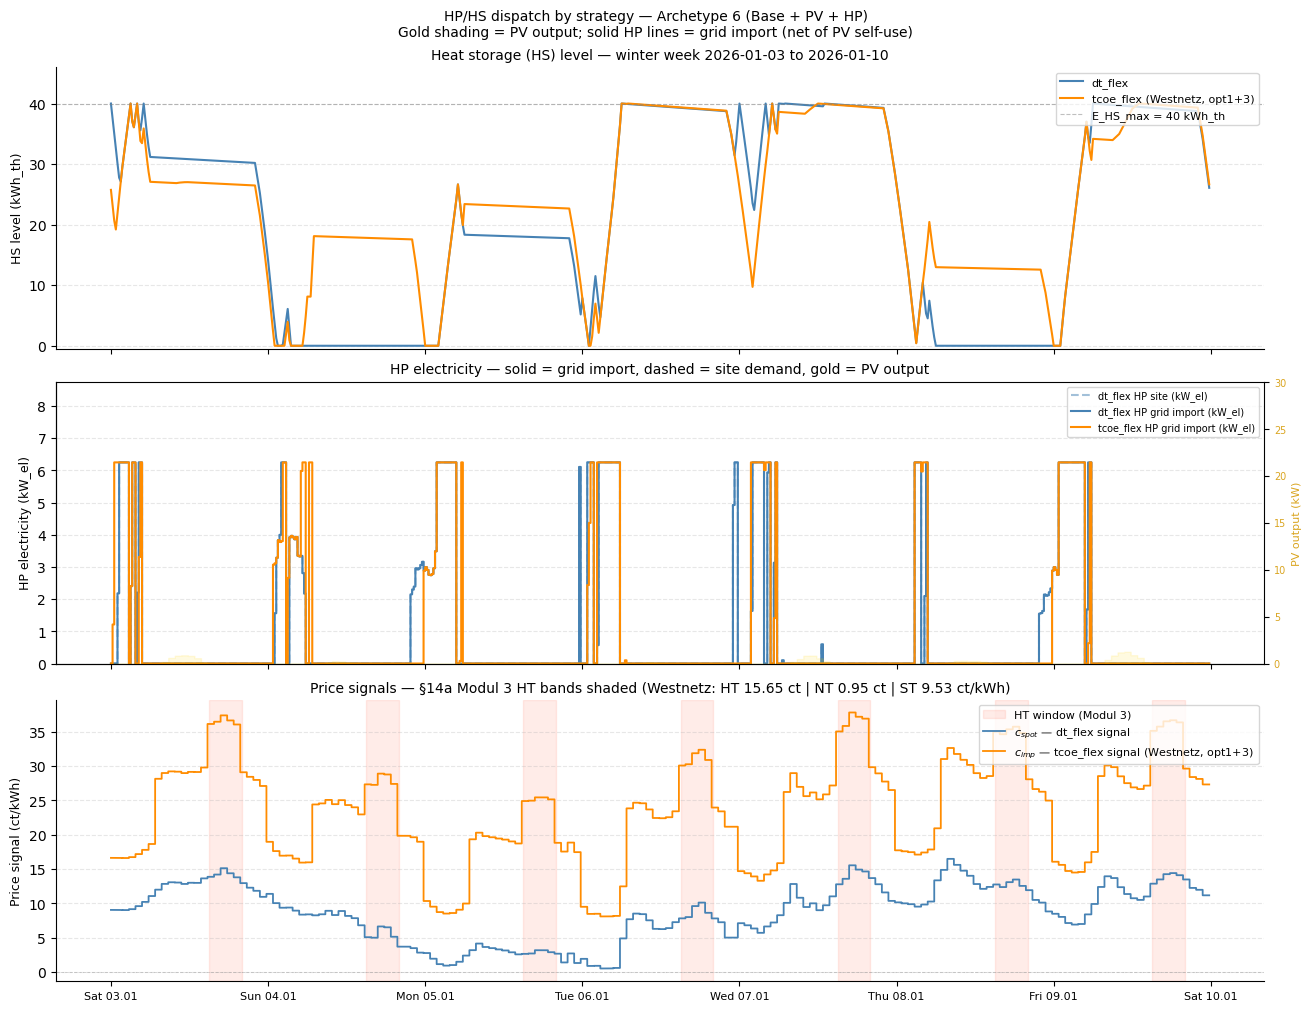

In [6]:
REF_DSO = 'Westnetz' if 'Westnetz' in schedules['tcoe_flex'] else next(iter(schedules['tcoe_flex']))
opt_tc  = schedules['tcoe_flex'][REF_DSO][3]
dbg_tc  = schedules['tcoe_flex'][REF_DSO][4]

Ehp_dt  = np.asarray(schedules['dt_flex'][2],                    dtype=float)  # HP grid import
Ehp_tc  = np.asarray(schedules['tcoe_flex'][REF_DSO][2],         dtype=float)

# HS state arrays (length T+1; drop last boundary for slot alignment)
Ehs_dt  = np.asarray(dbg_dt.get('E_HS', np.zeros(n+1)),  dtype=float)[:-1]
Ehs_tc  = np.asarray(dbg_tc.get('E_HS', np.zeros(n+1)),  dtype=float)[:-1]

# HP site demand from debug (P_HP_el * dt_h gives site kWh)
P_dt_arr = np.asarray(dbg_dt.get('P_HP_el', np.zeros(n)), dtype=float)
P_tc_arr = np.asarray(dbg_tc.get('P_HP_el', np.zeros(n)), dtype=float)
Ehp_site_dt = P_dt_arr * dt_h   # total HP electricity (site, before PV offset)
Ehp_site_tc = P_tc_arr * dt_h

# Build tcoe_flex price signal used for REF_DSO
dso_ref = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
base_ap = float(dso_ref['Arbeitspreis_ct_kWh'])
mod2_ct = float(dso_ref['Module2_ct_kWh'])
hp_mod3 = build_hp_dso_rate_mod3(df['timestamp'], REF_DSO, dso_ref)
HT_rate = float(dso_ref['HT_ct_kWh'])
ht_mask = (hp_mod3 == HT_rate)

if opt_tc == 'opt1':
    c_imp_tc = spot_arr + base_ap + TAX_PRE_VAT
elif opt_tc == 'opt2':
    c_imp_tc = spot_arr + mod2_ct  + TAX_PRE_VAT
else:
    c_imp_tc = spot_arr + hp_mod3  + TAX_PRE_VAT

# Winter week: first week in top-10% thermal-demand days
heat_daily = pd.Series(Q_heat_kWh, index=pd.to_datetime(df['timestamp'])).resample('D').sum()
win_start  = pd.Timestamp(heat_daily[heat_daily >= heat_daily.quantile(0.90)].index[0]).floor('D')
win_end    = win_start + pd.Timedelta(days=7)
mask       = ((df['timestamp'] >= win_start) & (df['timestamp'] < win_end)).values
x          = pd.to_datetime(df.loc[mask, 'timestamp'])

fig, (ax_hs, ax_hp, ax_pr) = plt.subplots(3, 1, figsize=(13, 10),
                                            constrained_layout=True, sharex=True)

# ── Panel 1: HS energy level ───────────────────────────────────────────────────
ax_hs.plot(x, Ehs_dt[mask], lw=1.5, color='steelblue',  label='dt_flex')
ax_hs.plot(x, Ehs_tc[mask], lw=1.5, color='darkorange', label=f'tcoe_flex ({REF_DSO}, {opt_tc})')
ax_hs.axhline(E_HS_max, color='grey', lw=0.8, ls='--', alpha=0.5, label=f'E_HS_max = {E_HS_max:.0f} kWh_th')
ax_hs.set_ylabel('HS level (kWh_th)', fontsize=9)
ax_hs.set_ylim(-0.5, E_HS_max * 1.15)
ax_hs.set_title(f'Heat storage (HS) level — winter week {win_start.date()} to {win_end.date()}', fontsize=10)
ax_hs.legend(loc='upper right', fontsize=8)
ax_hs.grid(axis='y', linestyle='--', alpha=0.3)
ax_hs.spines[['top', 'right']].set_visible(False)

# ── Panel 2: HP electricity draw + PV coverage shading ────────────────────────
# PV coverage of HP = site demand - grid import (the part covered by PV surplus)
pv_cov_dt = np.maximum(0.0, Ehp_site_dt[mask] - Ehp_dt[mask])  # PV used for HP (dt_flex)
pv_cov_tc = np.maximum(0.0, Ehp_site_tc[mask] - Ehp_tc[mask])  # PV used for HP (tcoe_flex)

ax_pv = ax_hp.twinx()
ax_pv.fill_between(x, 0, pv_arr[mask] * 4,   # kWh/slot -> kW
                   alpha=0.12, color='gold', step='pre', label='PV output (kW)')
ax_pv.set_ylabel('PV output (kW)', color='goldenrod', fontsize=8)
ax_pv.tick_params(axis='y', labelcolor='goldenrod', labelsize=7)
ax_pv.set_ylim(0, Q_HP_max_th * 1.5)

# HP site demand (total kW) and grid import portion
ax_hp.step(x, Ehp_site_dt[mask] * 4, where='pre', lw=1.5, color='steelblue',  alpha=0.5,
           ls='--', label='dt_flex HP site (kW_el)')
ax_hp.step(x, Ehp_dt[mask] * 4,      where='pre', lw=1.5, color='steelblue',
           label='dt_flex HP grid import (kW_el)')
ax_hp.step(x, Ehp_tc[mask] * 4,      where='pre', lw=1.5, color='darkorange',
           label=f'tcoe_flex HP grid import (kW_el)')
ax_hp.set_ylabel('HP electricity (kW_el)', fontsize=9)
ax_hp.set_ylim(0, P_HP_max_el * 1.4)
ax_hp.set_title('HP electricity — solid = grid import, dashed = site demand, gold = PV output', fontsize=10)
ax_hp.legend(loc='upper right', fontsize=7)
ax_hp.grid(axis='y', linestyle='--', alpha=0.3)
ax_hp.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Price signals with §14a HT band shading ─────────────────────────
ht_in_win = ht_mask[mask]
changes   = np.diff(np.concatenate([[False], ht_in_win, [False]]).astype(int))
ht_starts = np.where(changes ==  1)[0]
ht_ends   = np.where(changes == -1)[0]
for s, e in zip(ht_starts, ht_ends):
    ax_pr.axvspan(x.iloc[s], x.iloc[min(e, len(x)-1)],
                  alpha=0.12, color='tomato',
                  label='HT window (Modul 3)' if s == ht_starts[0] else '')

ax_pr.step(x, spot_arr[mask],   where='pre', lw=1.3, color='steelblue',
           label='$c_{spot}$ — dt_flex signal')
ax_pr.step(x, c_imp_tc[mask],   where='pre', lw=1.3, color='darkorange',
           label=f'$c_{{imp}}$ — tcoe_flex signal ({REF_DSO}, {opt_tc})')
ax_pr.axhline(0, color='grey', lw=0.6, ls='--', alpha=0.4)
ax_pr.set_ylabel('Price signal (ct/kWh)', fontsize=9)
ax_pr.set_title(f'Price signals — §14a Modul 3 HT bands shaded '
                f'({REF_DSO}: HT {dso_ref["HT_ct_kWh"]} ct | NT {dso_ref["NT_ct_kWh"]} ct | ST {dso_ref["ST_ct_kWh"]} ct/kWh)',
                fontsize=10)
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(axis='y', linestyle='--', alpha=0.3)
ax_pr.spines[['top', 'right']].set_visible(False)
ax_pr.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))
ax_pr.xaxis.set_major_locator(mdates.DayLocator())
ax_pr.tick_params(axis='x', labelsize=8)

fig.suptitle('HP/HS dispatch by strategy — Archetype 6 (Base + PV + HP)\n'
             'Gold shading = PV output; solid HP lines = grid import (net of PV self-use)',
             fontsize=10)
plt.show()


## Step 6 — Billing

**Billing note for this archetype:** DSO volumetric cost is split into two streams:
- **Base import** (fixed by PV allocation) → always billed at base Arbeitspreis
- **HP grid import** → billed at the option-specific §14a rate

Spot cost is net of PV export revenue. Levies apply to total grid import.


In [7]:
results = []
for _, dso_row in dso_tariffs.iterrows():
    dso_id = str(dso_row['DSO'])
    for strategy in ('no_flex', 'dt_flex', 'tcoe_flex'):
        if strategy == 'tcoe_flex':
            _val = schedules['tcoe_flex'][dso_id]
            E_g, E_f, E_hp = np.asarray(_val[0]), np.asarray(_val[1]), np.asarray(_val[2])
            opt = _val[3]
        else:
            E_g, E_f, E_hp = [np.asarray(x) for x in schedules[strategy]]
            opt = 'opt1'

        base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
        mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
        mod2_ct  = float(dso_row['Module2_ct_kWh'])

        cost_spot     = (np.sum(E_g * spot_arr) - np.sum(E_f * spot_arr)) / 100.0
        cost_base_vol = np.sum(base_import) * base_ap / 100.0

        if opt == 'opt1':
            cost_hp_vol = np.sum(E_hp) * base_ap / 100.0
            cost_mod1   = mod1_eur
        elif opt == 'opt2':
            cost_hp_vol = np.sum(E_hp) * mod2_ct / 100.0
            cost_mod1   = 0.0
        else:
            hp_r = build_hp_dso_rate_mod3(ts_idx, dso_id, dso_row)
            cost_hp_vol = np.sum(E_hp * hp_r) / 100.0
            cost_mod1   = mod1_eur

        cost_dso_vol = cost_base_vol + cost_hp_vol + cost_mod1
        cost_lev     = np.sum(E_g) * TAX_PRE_VAT / 100.0
        cost_fixed   = float(dso_row['Grundpreis_EUR_year'])
        subtotal     = cost_spot + cost_dso_vol + cost_lev + cost_fixed + SMART_OP_EUR
        vat          = VAT_RATE * subtotal

        results.append({
            'strategy'                     : strategy,
            'household_archetype'          : 6,
            'dso_id'                       : dso_id,
            'annual_energy_kwh'            : round(float(np.sum(E_g)), 2),
            'annual_feedin_kwh'            : round(float(np.sum(E_f)), 2),
            'cost_spot_net_eur'            : round(cost_spot,    2),
            'cost_dso_volumetric_net_eur'  : round(cost_dso_vol, 2),
            'cost_dso_fixed_net_eur'       : round(cost_fixed,   2),
            'cost_smart_operating_net_eur' : round(SMART_OP_EUR, 2),
            'cost_14a_mod1_net_eur'        : round(cost_mod1,    2),
            'cost_levies_pre_vat_eur'      : round(cost_lev,     2),
            'subtotal_net_eur'             : round(subtotal,     2),
            'vat_eur'                      : round(vat,          2),
            'total_tcoe_eur'               : round(subtotal + vat, 2),
            'billing_14a_option'           : opt,
            'optimized_14a_option'         : opt if strategy == 'tcoe_flex' else None,
        })

results = pd.DataFrame(results)
assert results['total_tcoe_eur'].notna().all(), 'NaN in total_tcoe_eur'
print(f'TCoE range (all 21 runs): {results["total_tcoe_eur"].min():.2f} – {results["total_tcoe_eur"].max():.2f} EUR/year')
print(f'Winning §14a options (tcoe_flex): {results[results["strategy"]=="tcoe_flex"]["billing_14a_option"].value_counts().to_dict()}')
results


TCoE range (all 21 runs): 699.39 – 1558.64 EUR/year
Winning §14a options (tcoe_flex): {'opt1+3': 7}


,strategy,household_archetype,dso_id,annual_energy_kwh,annual_feedin_kwh,cost_spot_net_eur,cost_dso_volumetric_net_eur,cost_dso_fixed_net_eur,cost_smart_operating_net_eur,cost_14a_mod1_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur,billing_14a_option,optimized_14a_option
0,no_flex,6,Westnetz,7138.78,9888.04,113.84,541.63,80.30,100.0,-138.70,474.02,1309.78,248.86,1558.64,opt1,None
1,dt_flex,6,Westnetz,7135.47,9787.76,-21.68,541.31,80.30,100.0,-138.70,473.80,1173.72,223.01,1396.73,opt1,None
2,tcoe_flex,6,Westnetz,5121.08,7766.97,13.26,141.21,80.30,100.0,-138.70,340.04,674.82,128.22,803.03,opt1+3,opt1+3
3,no_flex,6,Bayernwerk,7138.78,9888.04,113.84,213.77,98.55,100.0,-123.18,474.02,1000.17,190.03,1190.21,opt1,None
4,dt_flex,6,Bayernwerk,7135.47,9787.76,-21.68,213.61,98.55,100.0,-123.18,473.80,864.28,164.21,1028.49,opt1,None
5,tcoe_flex,6,Bayernwerk,5103.30,7752.41,8.95,115.50,98.55,100.0,-123.18,338.86,661.86,125.75,787.62,opt1+3,opt1+3
6,no_flex,6,E.DIS,7138.78,9888.04,113.84,282.24,76.65,100.0,-108.25,474.02,1046.74,198.88,1245.63,opt1,None
7,dt_flex,6,E.DIS,7135.47,9787.76,-21.68,282.06,76.65,100.0,-108.25,473.80,910.82,173.06,1083.88,opt1,None
8,tcoe_flex,6,E.DIS,5139.55,7787.59,9.19,60.62,76.65,100.0,-108.25,341.27,587.73,111.67,699.39,opt1+3,opt1+3
9,no_flex,6,Netze BW,7138.78,9888.04,113.84,359.63,84.00,100.0,-180.78,474.02,1131.48,214.98,1346.46,opt1,None


## Step 7 — Summary and export

In [8]:
# ── Table 1: no_flex cost breakdown (reference — comparable to Archetypes 1–5) ────
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id', 'cost_spot_net_eur', 'cost_dso_volumetric_net_eur',
        'cost_14a_mod1_net_eur', 'cost_dso_fixed_net_eur',
        'cost_smart_operating_net_eur', 'cost_levies_pre_vat_eur',
        'vat_eur', 'total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'               : 'Spot net (€)',
          'cost_dso_volumetric_net_eur'     : 'DSO vol (€)',
          'cost_14a_mod1_net_eur'           : '§14a Mod1 rebate (€)',
          'cost_dso_fixed_net_eur'          : 'DSO fix (€)',
          'cost_smart_operating_net_eur'    : 'Smart op. (€)',
          'cost_levies_pre_vat_eur'         : 'Levies pre-VAT (€)',
          'vat_eur'                         : 'VAT (€)',
          'total_tcoe_eur'                  : 'TCoE no_flex (€/yr)',
      }))

print(f'Annual: grid {E_grid_nf.sum():.1f} kWh  |  feed-in {E_feedin_nf.sum():.1f} kWh  '
      f'|  PV total {pv_arr.sum():.1f} kWh  |  HP site {E_hp_profile.sum():.1f} kWh')
print('\nTable 1 — no_flex cost breakdown (reference, §14a opt1):')
display(nf)

# ── Table 2: strategy comparison + flex savings ────────────────────────────────
piv = results.pivot_table(index='dso_id', columns='strategy',
                           values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex', 'dt_flex', 'tcoe_flex']]
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={
    'no_flex'   : 'TCoE no_flex (€/yr)',
    'dt_flex'   : 'TCoE dt_flex (€/yr)',
    'tcoe_flex' : 'TCoE tcoe_flex (€/yr)',
})
print('\nTable 2 — strategy comparison and flex savings vs no_flex:')
display(piv)

out = OUTPUTS / 'results_base_pv_hp_2026.csv'
results.to_csv(out, index=False)
print(f'\nSaved : {out}')
print(f'Rows  : {len(results)}  (3 strategies x 7 DSOs)')


Annual: grid 7138.8 kWh  |  feed-in 9888.0 kWh  |  PV total 11749.3 kWh  |  HP site 4500.0 kWh

Table 1 — no_flex cost breakdown (reference, §14a opt1):


,Spot net (€),DSO vol (€),§14a Mod1 rebate (€),DSO fix (€),Smart op. (€),Levies pre-VAT (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,,
Westnetz,113.84,541.63,-138.70,80.30,100.0,474.02,248.86,1558.64
Bayernwerk,113.84,213.77,-123.18,98.55,100.0,474.02,190.03,1190.21
E.DIS,113.84,282.24,-108.25,76.65,100.0,474.02,198.88,1245.63
Netze BW,113.84,359.63,-180.78,84.00,100.0,474.02,214.98,1346.46
Stromnetz Berlin,113.84,409.37,-123.18,33.36,100.0,474.02,214.81,1345.40
SH Netz,113.84,341.65,-115.23,94.90,100.0,474.02,213.64,1338.04
MITNETZ STROM,113.84,335.91,-114.55,73.00,100.0,474.02,208.38,1305.14



Table 2 — strategy comparison and flex savings vs no_flex:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,1190.21,1028.49,787.62,161.72,402.59
E.DIS,1245.63,1083.88,699.39,161.75,546.24
MITNETZ STROM,1305.14,1143.37,732.08,161.77,573.06
Netze BW,1346.46,1184.63,849.03,161.83,497.43
SH Netz,1338.04,1176.26,738.31,161.78,599.73
Stromnetz Berlin,1345.40,1183.57,744.04,161.83,601.36
Westnetz,1558.64,1396.73,803.03,161.91,755.61



Saved : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_pv_hp_2026.csv
Rows  : 21  (3 strategies x 7 DSOs)
